# Simulation Month — Week 4, Notebook 2
## Does Scarcity Change Which Command Structure Wins?

Notebook 1 showed one result at one unit count. This notebook holds the disaster fixed (same fire, same seed) and varies the *number of response units* — testing whether the centralized coordinator's disadvantage is a general property, or something that only shows up once there are enough units for reassignment churn to matter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import os

EMPTY, TREE, BURNING = 0, 1, 2
FIRE_PALETTE = ListedColormap(["#D4A574", "#3D5A45", "#E8871E"])  # sand, forest, ember
UNIT_COLOR = "#2E5C8A"   # steel blue — response units, distinct from the fire palette

NATURAL_PALETTE = {
    "unaware": "#8B5E3C", "engaged": "#6B8E4E", "disengaged": "#3D5A45",
    "accent": "#D4A574", "highlight": "#4A6741",
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#3D5A45"
plt.rcParams["font.size"] = 11

FIG_DIR = "/mnt/user-data/outputs/figures"
VIDEO_DIR = "/mnt/user-data/outputs/videos"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
def burning_neighbor_mask(grid):
    burning = (grid == BURNING)
    mask = np.zeros_like(burning)
    mask[1:, :]  |= burning[:-1, :]
    mask[:-1, :] |= burning[1:, :]
    mask[:, 1:]  |= burning[:, :-1]
    mask[:, :-1] |= burning[:, 1:]
    return mask

def step(grid, p, f, rng):
    new_grid = grid.copy()
    burning = grid == BURNING
    tree = grid == TREE
    empty = grid == EMPTY
    neighbor_burning = burning_neighbor_mask(grid)
    new_grid[burning] = EMPTY
    ignite_spread = tree & neighbor_burning
    new_grid[ignite_spread] = BURNING
    remaining_trees = tree & ~neighbor_burning
    lightning_strikes = remaining_trees & (rng.random(grid.shape) < f)
    new_grid[lightning_strikes] = BURNING
    grow = empty & (rng.random(grid.shape) < p)
    new_grid[grow] = TREE
    n_new = int(ignite_spread.sum() + lightning_strikes.sum())
    return new_grid, n_new, lightning_strikes

def seed_forest(size, density, rng):
    grid = np.zeros((size, size), dtype=int)
    grid[rng.random((size, size)) < density] = TREE
    return grid

def nearest_tree_to_center(grid):
    ys, xs = np.where(grid == TREE)
    c = grid.shape[0] // 2
    dists = (ys - c) ** 2 + (xs - c) ** 2
    i = np.argmin(dists)
    return int(ys[i]), int(xs[i])

In [3]:
from scipy.optimize import linear_sum_assignment

def cheby(a, b):
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]))

def get_stations(n_units, size):
    """Place fire stations in a ring around the forest, surrounding it evenly —
    the same station layout is used for both strategies so any outcome
    difference is attributable to dispatch logic, not starting position."""
    center = size / 2
    radius = size * 0.45
    angles = np.linspace(0, 2 * np.pi, n_units, endpoint=False)
    stations = []
    for a in angles:
        y = int(np.clip(center + radius * np.sin(a), 0, size - 1))
        x = int(np.clip(center + radius * np.cos(a), 0, size - 1))
        stations.append((y, x))
    return stations

def assign_centralized(unit_positions, burning_cells, max_candidates=60):
    """A single commander with full visibility assigns units to minimize total
    travel distance, using the Hungarian algorithm for a genuinely optimal
    (not just deduplicated) match. Candidates are capped near the unit
    centroid for speed when the fire front is large."""
    if len(burning_cells) > max_candidates:
        centroid = np.mean(unit_positions, axis=0)
        d = [cheby(centroid, c) for c in burning_cells]
        idx = np.argsort(d)[:max_candidates]
        candidates = [burning_cells[i] for i in idx]
    else:
        candidates = burning_cells

    cost = np.array([[cheby(u, c) for c in candidates] for u in unit_positions])
    row_ind, col_ind = linear_sum_assignment(cost)
    assignments = [None] * len(unit_positions)
    for r, c in zip(row_ind, col_ind):
        assignments[r] = candidates[c]
    return assignments

def assign_decentralized(unit_positions, burning_cells):
    """Each unit independently heads for its own nearest burning cell — no
    coordinator, no visibility into what other units are doing."""
    assignments = []
    for pos in unit_positions:
        if not burning_cells:
            assignments.append(None)
            continue
        best = min(burning_cells, key=lambda c: cheby(pos, c))
        assignments.append(best)
    return assignments

def move_towards(pos, target):
    y, x = pos
    ty, tx = target
    dy = int(np.sign(ty - y))
    dx = int(np.sign(tx - x))
    return (y + dy, x + dx)

def run_response_sim(grid, stations, strategy, rng, max_steps=150, record_frames=False):
    """Each step: units retarget and move one cell toward their target, any unit
    now standing on a burning cell suppresses it, then the fire spreads
    naturally (no growth/lightning — this is a single-disaster response
    scenario, not the ongoing regrowth process from Week 3)."""
    grid = grid.copy()
    units = list(stations)
    suppressed_count = 0
    steps_taken = 0
    frames = [(grid.copy(), list(units))] if record_frames else None

    for t in range(max_steps):
        burning_cells = [tuple(c) for c in np.argwhere(grid == BURNING)]
        if not burning_cells:
            break

        targets = ([] if not units else
                   (assign_centralized(units, burning_cells) if strategy == "centralized"
                    else assign_decentralized(units, burning_cells)))
        units = [pos if target is None else move_towards(pos, target)
                 for pos, target in zip(units, targets)]

        for pos in units:
            if grid[pos[0], pos[1]] == BURNING:
                grid[pos[0], pos[1]] = EMPTY
                suppressed_count += 1

        grid, _, _ = step(grid, p=0.0, f=0.0, rng=rng)
        steps_taken = t + 1
        if record_frames:
            frames.append((grid.copy(), list(units)))
        if not (grid == BURNING).any():
            break

    result = {"final_grid": grid, "suppressed": suppressed_count, "steps": steps_taken}
    if record_frames:
        result["frames"] = frames
    return result

## Matched fire, two unit counts

Same disaster draw, same station ring geometry, just scaled to different unit counts — a scarce response (2 units) and a well-resourced one (8 units).

In [4]:
SIZE = 60
DENSITY = 0.65

rng = np.random.default_rng(3)
base_grid = seed_forest(SIZE, DENSITY, rng)
iy, ix = nearest_tree_to_center(base_grid)
base_grid[iy, ix] = BURNING
initial_trees = int((base_grid == TREE).sum()) + 1

results = {}
for n_units in [2, 8]:
    stations = get_stations(n_units, SIZE)
    for strategy in ["centralized", "decentralized"]:
        r = run_response_sim(base_grid.copy(), stations, strategy, np.random.default_rng(1))
        burned = initial_trees - int((r["final_grid"] == TREE).sum())
        results[(n_units, strategy)] = {"burned": burned, "steps": r["steps"]}
        print(f"{n_units} units, {strategy}: {burned} burned "
              f"({burned/initial_trees*100:.1f}%), {r['steps']} steps")

2 units, centralized: 1295 burned (55.6%), 116 steps
2 units, decentralized: 1250 burned (53.6%), 122 steps
8 units, centralized: 209 burned (9.0%), 32 steps
8 units, decentralized: 179 burned (7.7%), 31 steps


## Where the two strategies leave a different forest standing

For a representative unit count, a direct spatial diff of the final grids shows exactly which cells one strategy saved that the other didn't.

saved /mnt/user-data/outputs/figures/week4_strategy_diff_map.png


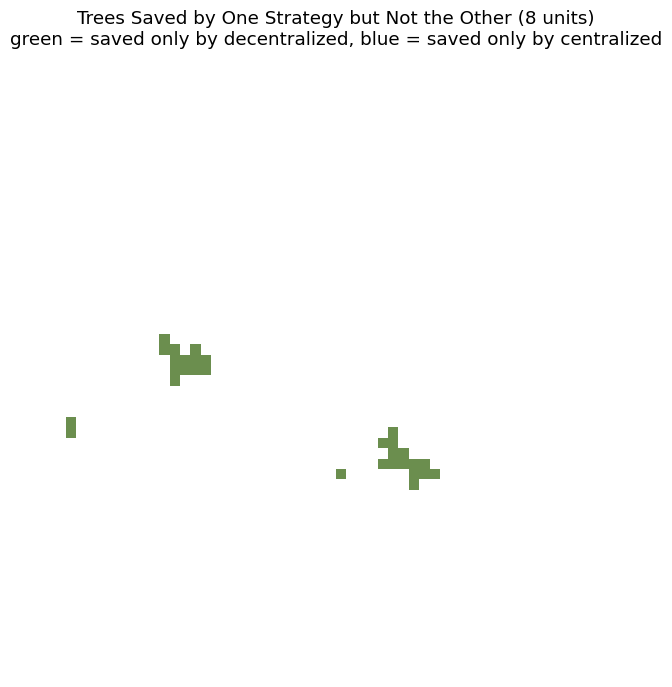

Cells saved only by decentralized: 30
Cells saved only by centralized: 0


In [5]:
n_units_compare = 8
stations = get_stations(n_units_compare, SIZE)
r_c = run_response_sim(base_grid.copy(), stations, "centralized", np.random.default_rng(1))
r_d = run_response_sim(base_grid.copy(), stations, "decentralized", np.random.default_rng(1))

saved_by_decentralized_only = (r_d["final_grid"] == TREE) & (r_c["final_grid"] != TREE)
saved_by_centralized_only = (r_c["final_grid"] == TREE) & (r_d["final_grid"] != TREE)

diff_map = np.zeros((SIZE, SIZE, 3))
diff_map[..., :] = [1, 1, 1]
diff_map[saved_by_decentralized_only] = plt.matplotlib.colors.to_rgb(NATURAL_PALETTE["engaged"])
diff_map[saved_by_centralized_only] = plt.matplotlib.colors.to_rgb("#2E5C8A")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(diff_map)
ax.set_title(f"Trees Saved by One Strategy but Not the Other ({n_units_compare} units)\n"
             f"green = saved only by decentralized, blue = saved only by centralized")
ax.axis("off")
plt.tight_layout()
savefig(fig, "week4_strategy_diff_map")
plt.show()

print(f"Cells saved only by decentralized: {saved_by_decentralized_only.sum()}")
print(f"Cells saved only by centralized: {saved_by_centralized_only.sum()}")

## What Notebook 2 establishes

At 2 units, the two strategies are close — there's little redundancy risk for a coordinator to prevent when units are this scarce, so the "optimal" assignment barely differs from independent greedy behavior. At 8 units, the gap is much larger, and it favors the *uncoordinated* strategy — more units means more opportunities for the global-optimal reassignment to redirect a unit mid-approach, while independent greedy units never get pulled off a target they're already closing in on.

**Notebook 3** scales this to 40 disaster draws across a fuller range of unit counts, to confirm this crossover is a real, robust pattern rather than one seed's coincidence.